# 15. 자문안으로 MC 재산출 — 자문 전후 비교 (EWMA-120 변동성 · 120일 상관)

`1_MC_recompute` 의 MC 이론가를 자문에서 제안된 변동성·상관 정의로 다시 뽑고, 노트북 1 의 두 그림
(`공정가 − MC` 히스토그램, 가격구간별 오차)을 **자문 전후**로 겹쳐 본다.

| | 자문 전 (정본 `mc`) | 자문 후 |
|---|---|---|
| 변동성 | 발행 전 **180 거래일** 로그수익률 단순 표준편차 × √252 | 발행 전 **120 거래일 EWMA** 표준편차 × √252 |
| 가중치 | 180일 모두 같은 가중 | span 120 → λ = 1 − 2/121 ≈ **0.9835**, 반감기 ≈ **42 거래일** (창 안에서 재정규화) |
| 상관 | 3시장 공통 거래일 **180일** Pearson | 3시장 공통 거래일 **120일** Pearson |
| 나머지 | 일별 GBM · 촐레스키 · NS 할인 · q=0 · 40,000 경로 · seed=`mc_seed` | 동일 |

## 공통난수 — 변동성·상관만 다르게

자문 후 가격은 정본과 같은 엔진·할인·**40,000 경로·같은 시드**로 계산했다. 180일 입력을 넣으면 정본 `mc` 를
**오차 0.00원으로 비트 단위 재현**한다(150건 확인). 따라서 전후 차이는 오직 변동성·상관 정의에서 온다.
정본 `mc`·`mccal_shard` 는 건드리지 않았고 결과는 `data/cache/mc_ewma120/` 에 있다
(`scratch/mc_ewma120_recompute.py`, 정의는 `module/features.py` 의 `vol_ewma` · `corr180(win=120)`).

효과 분리를 위해 5개 중 1개 상품(`mc_seed % 5 == 0`, 약 11,800개)은 **EWMA 변동성 + 180일 상관**(V)도
가격했다 → `V − 전` = 변동성 효과, `후 − V` = 상관 효과.


In [1]:
import glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from util import file_manager as fm, plot as _plot     # import 만으로 dpi400·투명·PPT 밴드

FACE = 10000
BEF, AFT = "#e07a5f", "#1f6f9c"                        # 5_MC_implied_vol 겹침 히스토그램과 같은 색
LB, LA = "before advisory: HV 180d, corr 180d", "after advisory: EWMA 120d, corr 120d"

base = pd.read_parquet(fm.source()).sort_values("isu_ord").reset_index(drop=True)
R = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(str(fm.CACHE / "mc_ewma120" / "chunk_*.parquet")))],
              ignore_index=True).sort_values("i").set_index("i")
assert len(R) == len(base), f"재가격 결과 {len(R)} != 상품 {len(base)} (chunk 누락)"

d = base[["item", "isu_ord", "fair", "mc", "opt_type", "ki_yn"]].copy()
d["status"] = R["status"].reindex(d.index)
d["mc_bef"] = d["mc"]
d["mc_aft"] = R["mc_VC"].reindex(d.index).fillna(d["mc"])      # 폴백 상품은 정본 값 그대로
d["mc_V"] = R["mc_V"].reindex(d.index)                          # 분해용 (5개 중 1개)
AUD = [f"hv{j}" for j in range(3)] + [f"ew{j}" for j in range(3)] + \
      [f"rho{w}_{p}" for w in (180, 120) for p in ("01", "02", "12")]
for c in AUD:
    d[c] = R[c].reindex(d.index)
d["year"] = d.isu_ord.map(lambda o: pd.Timestamp.fromordinal(int(o)).year)
d["err_bef"] = (d.fair - d.mc_bef) * FACE
d["err_aft"] = (d.fair - d.mc_aft) * FACE

print(f"상품 {len(d):,} | 상태 {d.status.value_counts().to_dict()} | 분해 표본 {int(d.mc_V.notna().sum()):,}")
hv = d[[f"hv{j}" for j in range(3)]].values; ew = d[[f"ew{j}" for j in range(3)]].values
r180 = d[[f"rho180_{p}" for p in ("01", "02", "12")]].values
r120 = d[[f"rho120_{p}" for p in ("01", "02", "12")]].values
print(f"변동성 평균  전 {np.nanmean(hv)*100:.2f}%  ->  후 {np.nanmean(ew)*100:.2f}%   "
      f"(후/전 비율 중앙값 {np.nanmedian(ew/hv):.3f})")
print(f"상관 평균    전 {np.nanmean(r180):.3f}  ->  후 {np.nanmean(r120):.3f}   "
      f"(차이 |평균| {np.nanmean(np.abs(r120-r180)):.3f})")

상품 58,790 | 상태 {'ok': 58790} | 분해 표본 11,758
변동성 평균  전 18.46%  ->  후 18.26%   (후/전 비율 중앙값 0.979)
상관 평균    전 0.350  ->  후 0.348   (차이 |평균| 0.050)


## 15-1. 전체 요약 — 오차가 줄었는가

`공정가 − MC` 가 0 에 가까울수록 MC 가 공정가를 잘 맞춘 것이다. 음수는 MC 과대평가.


In [2]:
def summ(e, mc):
    return {"mean_err_KRW": e.mean(), "median_err_KRW": e.median(), "MAE_KRW": e.abs().mean(),
            "RMSE_KRW": np.sqrt((e ** 2).mean()), "MAPE%": (e.abs() / (d.fair * FACE)).mean() * 100,
            "R2": r2_score(d.fair, mc)}


S = pd.DataFrame({"before": summ(d.err_bef, d.mc_bef), "after": summ(d.err_aft, d.mc_aft)}).T
S.loc["after - before"] = S.loc["after"] - S.loc["before"]
S.to_csv(fm.stat("mc_adv_summary"))
print(S.round(3).to_string())
better = (d.err_aft.abs() < d.err_bef.abs()).mean()
print(f"\n|오차| 가 줄어든 상품 {better*100:.1f}%  |  MC 가격 변화 (후 − 전) 평균 "
      f"{((d.mc_aft - d.mc_bef) * FACE).mean():+,.0f}원, 표준편차 {((d.mc_aft - d.mc_bef) * FACE).std():,.0f}원")

                mean_err_KRW  median_err_KRW  MAE_KRW  RMSE_KRW  MAPE%     R2
before              -556.029        -568.897  613.691   725.223  6.785 -1.401
after               -550.080        -580.455  649.640   763.234  7.183 -1.659
after - before         5.949         -11.558   35.949    38.011  0.398 -0.258

|오차| 가 줄어든 상품 43.7%  |  MC 가격 변화 (후 − 전) 평균 -6원, 표준편차 301원


## 15-2. 노트북 1 그림 ① — `(공정가 − MC)` 히스토그램, 자문 전후 겹침

`5_MC_implied_vol` 의 역사 vs 내재 겹침 그림과 같은 형식이다. 두 분포는 같은 구간(bin)을 쓴다.


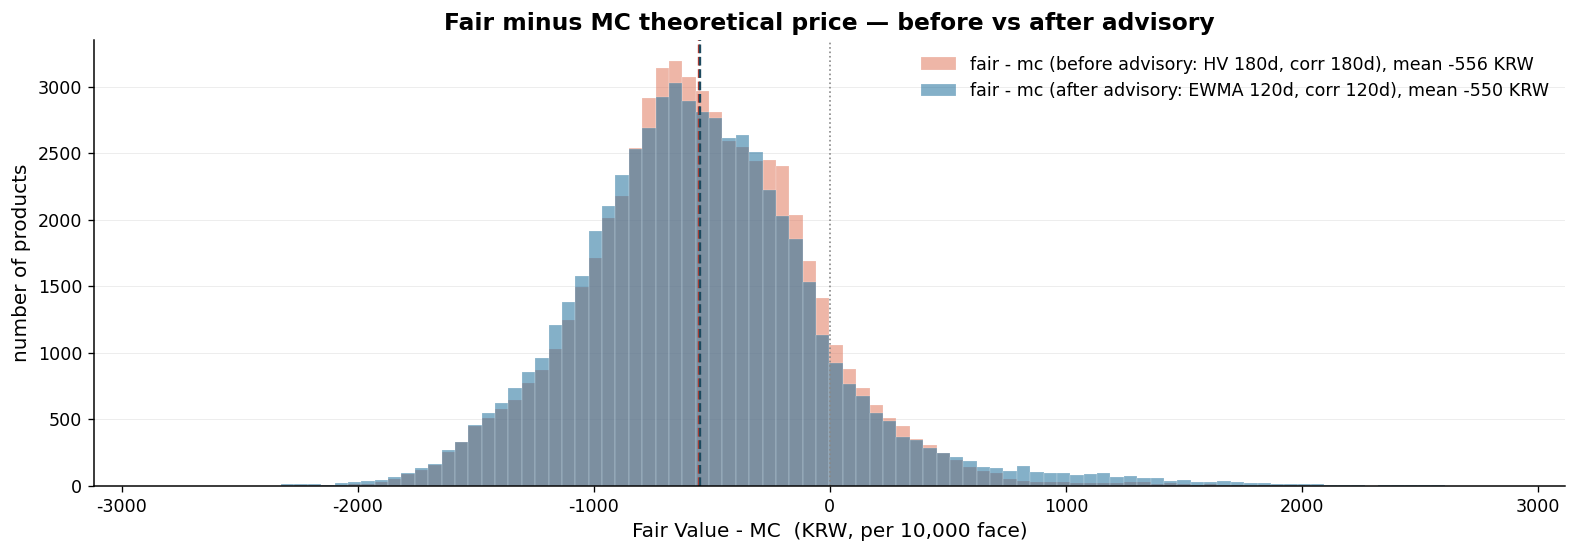

fair-mc 전 -556 | 후 -550 | 편향 변화 +6 KRW
saved -> mc_adv_fair_minus_mc_hist.png


In [3]:
e_b, e_a = d.err_bef, d.err_aft
bins = np.linspace(min(e_b.min(), e_a.min()), max(e_b.max(), e_a.max()), 101)
fig, ax = plt.subplots(figsize=(13.333, 4.8))
ax.hist(e_b, bins=bins, color=BEF, alpha=.55, edgecolor="white", lw=.2,
        label=f"fair - mc ({LB}), mean {e_b.mean():,.0f} KRW")
ax.hist(e_a, bins=bins, color=AFT, alpha=.55, edgecolor="white", lw=.2,
        label=f"fair - mc ({LA}), mean {e_a.mean():,.0f} KRW")
ax.axvline(e_b.mean(), color="#c0392b", lw=1.4, ls="--"); ax.axvline(e_a.mean(), color="#1c4a5f", lw=1.4, ls="--")
ax.axvline(0, color="#888", lw=1, ls=":")
ax.set_xlabel("Fair Value - MC  (KRW, per 10,000 face)"); ax.set_ylabel("number of products")
ax.set_title("Fair minus MC theoretical price — before vs after advisory")
ax.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6); ax.legend()
fig.tight_layout(); fig.savefig(fm.image("mc_adv_fair_minus_mc_hist")); plt.show()
print(f"fair-mc 전 {e_b.mean():,.0f} | 후 {e_a.mean():,.0f} | 편향 변화 {e_a.mean()-e_b.mean():+,.0f} KRW")
print("saved ->", fm.image("mc_adv_fair_minus_mc_hist").name)

## 15-3. 노트북 1 그림 ② — 가격구간별 오차 · MAPE, 자문 전후

노트북 1 은 **저가(위험) 구간에서 MC 가 크게 과대평가**하는 것을 역사변동성이 하방 스큐를 못 담는 흔적으로 봤다.
변동성·상관 정의를 바꾸면 그 기울기가 달라지는지 본다.


                   n  fair_mean  err_bef  err_aft  MAPE_bef  MAPE_aft
price_seg                                                            
(0.699, 0.884]  9799       0.85 -1004.13 -1063.68     12.52     13.58
(0.884, 0.912]  9798       0.90  -778.54  -778.88      9.21      9.50
(0.912, 0.933]  9799       0.92  -668.20  -648.19      7.51      7.70
(0.933, 0.953]  9797       0.94  -501.03  -481.26      5.75      5.95
(0.953, 0.976]  9800       0.96  -322.71  -294.47      3.75      4.04
(0.976, 1.05]   9797       0.99   -61.50   -33.94      1.97      2.32


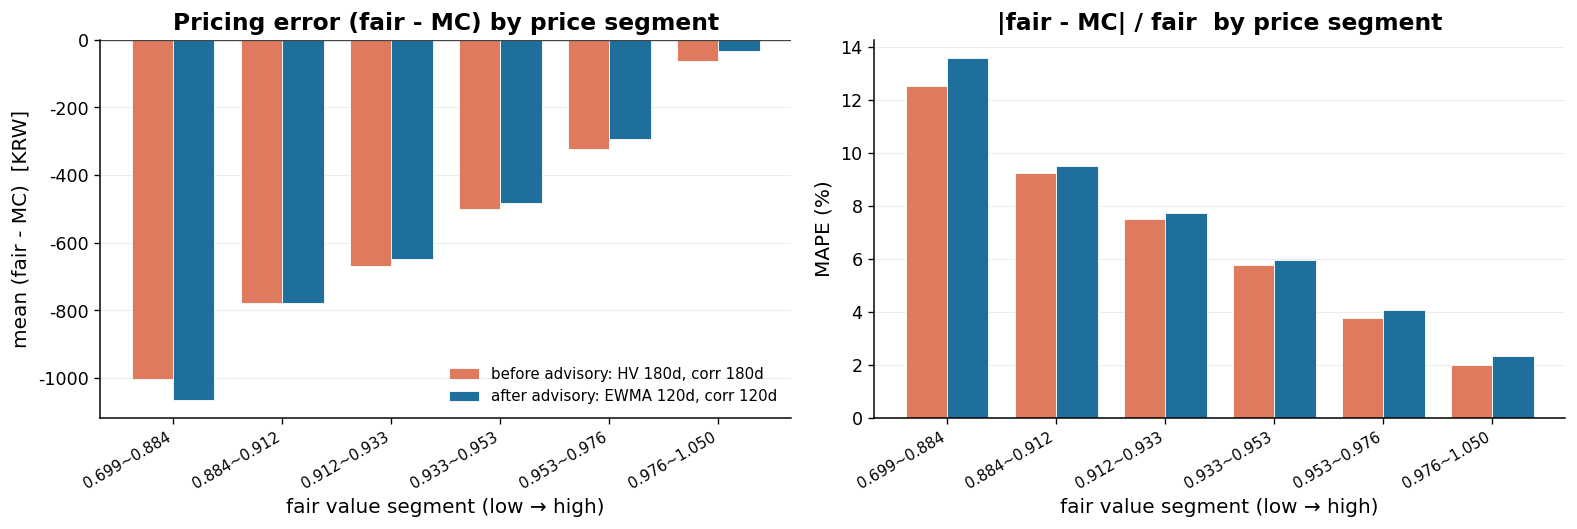

구간 기울기 (최안전 − 최위험 구간 평균오차): 전 943원 → 후 1,030원
saved -> mc_adv_err_by_price_seg.png


In [4]:
d["price_seg"] = pd.qcut(d.fair, 6)
d["ape_bef"] = d.err_bef.abs() / (d.fair * FACE) * 100
d["ape_aft"] = d.err_aft.abs() / (d.fair * FACE) * 100
g = d.groupby("price_seg", observed=True).agg(
    n=("fair", "size"), fair_mean=("fair", "mean"),
    err_bef=("err_bef", "mean"), err_aft=("err_aft", "mean"),
    MAPE_bef=("ape_bef", "mean"), MAPE_aft=("ape_aft", "mean"))
g.to_csv(fm.stat("mc_adv_by_price_seg"))
print(g.round(2).to_string())

xs = np.arange(len(g)); xl = [f"{iv.left:.3f}~{iv.right:.3f}" for iv in g.index]; w = .38
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))
for a, cb, ca, yl, tt in [(ax[0], "err_bef", "err_aft", "mean (fair - MC)  [KRW]", "Pricing error (fair - MC) by price segment"),
                          (ax[1], "MAPE_bef", "MAPE_aft", "MAPE (%)", "|fair - MC| / fair  by price segment")]:
    a.bar(xs - w/2, g[cb].values, w, color=BEF, edgecolor="white", linewidth=.5, label=LB)
    a.bar(xs + w/2, g[ca].values, w, color=AFT, edgecolor="white", linewidth=.5, label=LA)
    a.axhline(0, color="#444", lw=.8)
    a.set_xticks(xs); a.set_xticklabels(xl, rotation=30, fontsize=9, ha="right")
    a.set_ylabel(yl); a.set_xlabel("fair value segment (low → high)"); a.set_title(tt)
    a.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)
ax[0].legend(fontsize=9, loc="lower right")
fig.tight_layout(); fig.savefig(fm.image("mc_adv_err_by_price_seg")); plt.show()
print(f"구간 기울기 (최안전 − 최위험 구간 평균오차): 전 {g.err_bef.iloc[-1]-g.err_bef.iloc[0]:,.0f}원 → "
      f"후 {g.err_aft.iloc[-1]-g.err_aft.iloc[0]:,.0f}원")
print("saved ->", fm.image("mc_adv_err_by_price_seg").name)

## 15-4. 입력이 어떻게 바뀌었고, 무엇이 가격을 움직였나

왼쪽 두 그림은 상품별 입력 변화(기초자산 3개 · 상관 3쌍을 모두 쌓음), 오른쪽은 분해 표본에서의 MC 가격 변화다.
공통난수라 각 조각이 순수하게 그 요인의 몫이다. 상품마다 부호가 엇갈려 **평균 변화는 상쇄**되므로,
막대는 상품별 변화의 **크기 |Δ| 평균**이고 괄호 안 숫자가 부호 있는 평균이다.


=== MC 가격 변화 분해 (원, 음수 = MC 가 싸짐) ===
             mean  mean |Δ|    std
volatility   -6.6     171.9  308.1
correlation   1.2       6.2   13.2
total        -5.4     169.5  301.5


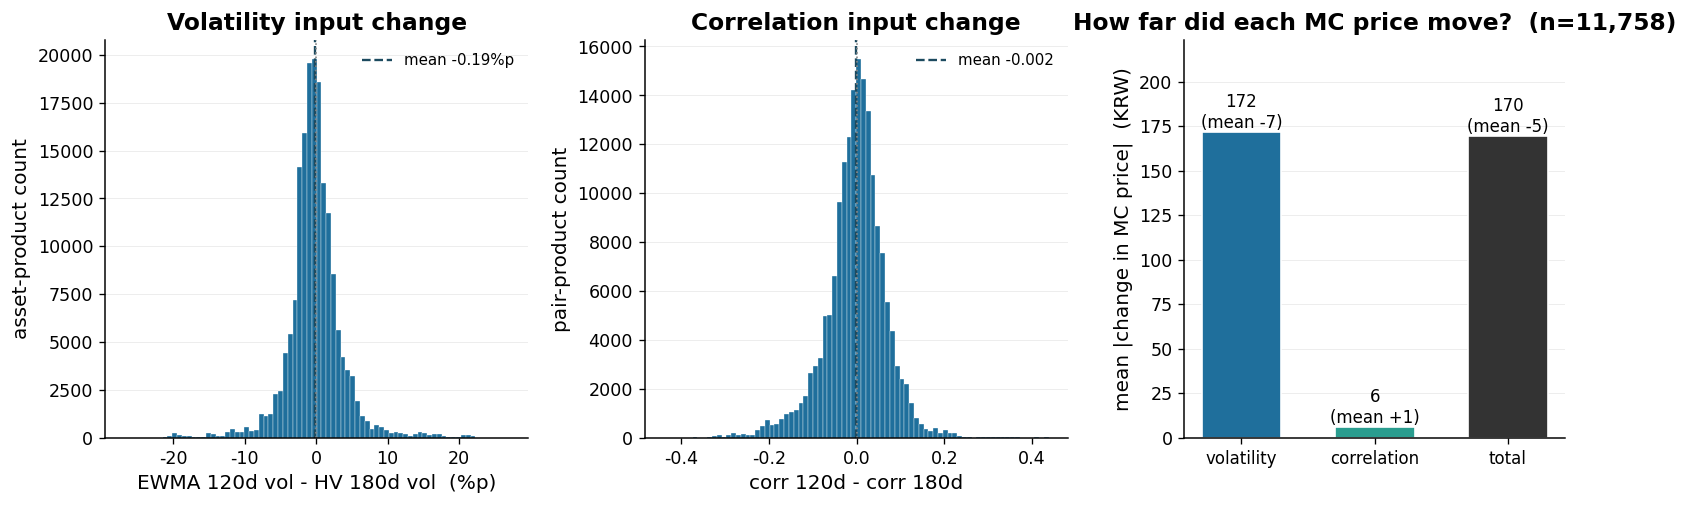

saved -> mc_adv_inputs_decomposition.png


In [5]:
dv = ((ew - hv) * 100).ravel(); dr = (r120 - r180).ravel()
D = d[d.mc_V.notna()]
DEC = pd.DataFrame({"volatility": (D.mc_V - D.mc_bef) * FACE, "correlation": (D.mc_aft - D.mc_V) * FACE,
                    "total": (D.mc_aft - D.mc_bef) * FACE})
DEC.describe().to_csv(fm.stat("mc_adv_decomposition"))
print("=== MC 가격 변화 분해 (원, 음수 = MC 가 싸짐) ===")
print(pd.DataFrame({"mean": DEC.mean(), "mean |Δ|": DEC.abs().mean(), "std": DEC.std()}).round(1).to_string())

fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.4), gridspec_kw={"width_ratios": [1, 1, .9]})
ax[0].hist(dv[np.isfinite(dv)], bins=80, color=AFT, edgecolor="white", lw=.2)
ax[0].axvline(np.nanmean(dv), color="#1c4a5f", lw=1.4, ls="--", label=f"mean {np.nanmean(dv):+.2f}%p")
ax[0].axvline(0, color="#888", lw=1, ls=":")
ax[0].set_xlabel("EWMA 120d vol - HV 180d vol  (%p)"); ax[0].set_ylabel("asset-product count")
ax[0].set_title("Volatility input change"); ax[0].legend(fontsize=9)
ax[1].hist(dr[np.isfinite(dr)], bins=80, color=AFT, edgecolor="white", lw=.2)
ax[1].axvline(np.nanmean(dr), color="#1c4a5f", lw=1.4, ls="--", label=f"mean {np.nanmean(dr):+.3f}")
ax[1].axvline(0, color="#888", lw=1, ls=":")
ax[1].set_xlabel("corr 120d - corr 180d"); ax[1].set_ylabel("pair-product count")
ax[1].set_title("Correlation input change"); ax[1].legend(fontsize=9)
absm, sgnm = DEC.abs().mean(), DEC.mean()
ax[2].bar(range(3), absm.values, color=[AFT, "#2a9d8f", "#333333"], edgecolor="white", width=.6)
for j, nm in enumerate(DEC.columns):
    ax[2].text(j, absm[nm], f"{absm[nm]:.0f}\n(mean {sgnm[nm]:+.0f})", ha="center", va="bottom", fontsize=10)
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(DEC.columns, fontsize=10)
ax[2].set_ylim(0, absm.max() * 1.3); ax[2].set_ylabel("mean |change in MC price|  (KRW)")
ax[2].set_title(f"How far did each MC price move?  (n={len(D):,})")
for a in ax:
    a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("mc_adv_inputs_decomposition")); plt.show()
print("saved ->", fm.image("mc_adv_inputs_decomposition").name)

## 15-5. 시기별 — EWMA 는 최근 변동에 빨리 반응한다

120일 창 안에서 EWMA 는 최근 42 거래일에 가중치의 약 58% 를 둔다 (180일 단순평균은 23%).
변동성이 급변한 시기(2020 코로나, 2022 긴축)에 발행된 상품에서 전후 차이가 클 것이다.


         n  err_bef  err_aft  mae_bef  mae_aft
year                                          
2015  4135   -546.0   -410.0    599.0    498.0
2016  3846   -353.0   -448.0    391.0    474.0
2017  5000   -697.0   -734.0    715.0    749.0
2018  6657   -534.0   -489.0    558.0    524.0
2019  8005   -548.0   -586.0    560.0    597.0
2020  5160    -60.0    -67.0    478.0    752.0
2021  7045  -1001.0  -1046.0   1012.0   1054.0
2022  5705   -773.0   -642.0    784.0    680.0
2023  5432   -684.0   -777.0    691.0    779.0
2024  3101   -374.0   -307.0    396.0    399.0
2025  3535   -160.0   -207.0    236.0    351.0
2026  1169   -366.0    -24.0    380.0    341.0


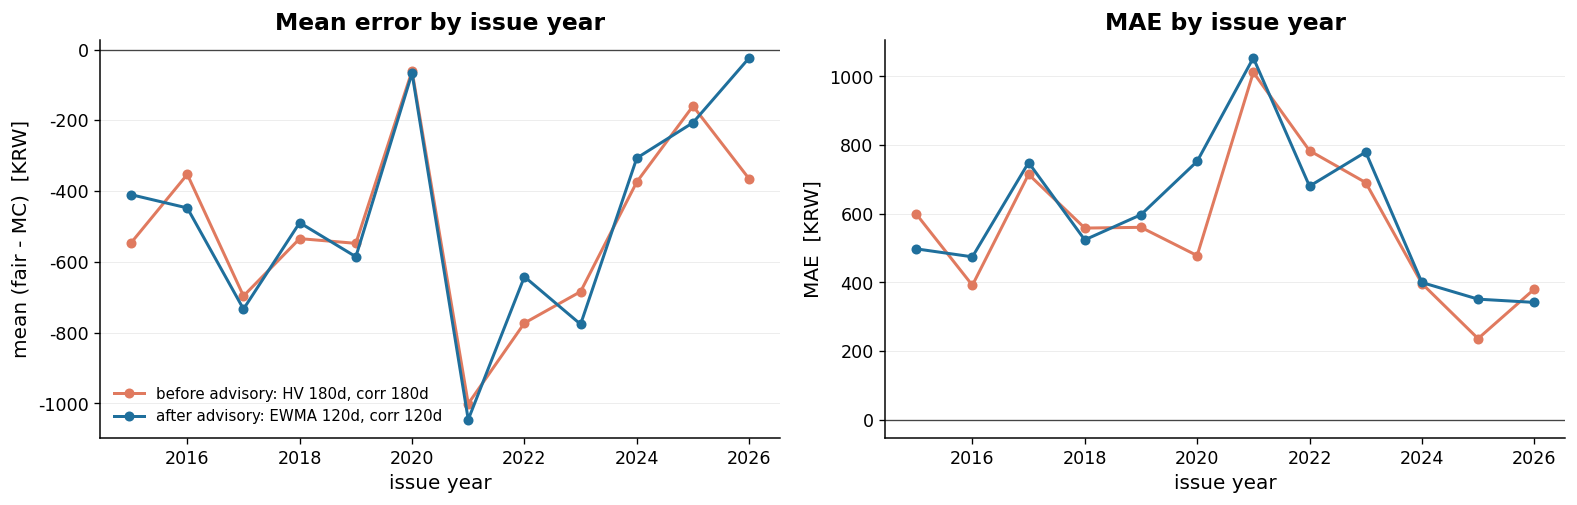

saved -> mc_adv_by_year.png


In [6]:
t = d.groupby("year").agg(n=("fair", "size"), err_bef=("err_bef", "mean"), err_aft=("err_aft", "mean"),
                          mae_bef=("err_bef", lambda s: s.abs().mean()), mae_aft=("err_aft", lambda s: s.abs().mean()))
t.to_csv(fm.stat("mc_adv_by_year"))
print(t.round(0).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.4))
for a, cb, ca, yl, tt in [(ax[0], "err_bef", "err_aft", "mean (fair - MC)  [KRW]", "Mean error by issue year"),
                          (ax[1], "mae_bef", "mae_aft", "MAE  [KRW]", "MAE by issue year")]:
    a.plot(t.index, t[cb], "o-", ms=5, lw=1.8, color=BEF, label=LB)
    a.plot(t.index, t[ca], "o-", ms=5, lw=1.8, color=AFT, label=LA)
    a.axhline(0, color="#444", lw=.8); a.set_xlabel("issue year"); a.set_ylabel(yl); a.set_title(tt)
    a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
ax[0].legend(fontsize=9)
fig.tight_layout(); fig.savefig(fm.image("mc_adv_by_year")); plt.show()
print("saved ->", fm.image("mc_adv_by_year").name)

## 결론 — 자문안(EWMA-120 · 상관 120일)은 MC 오차를 줄이지 못한다

전 상품 58,790개, 공통난수(같은 경로) 기준.

| | 자문 전 (HV 180 · 상관 180) | 자문 후 (EWMA 120 · 상관 120) | 변화 |
|---|---|---|---|
| 평균 오차 (공정가 − MC) | −556원 | −550원 | +6원 |
| MAE | 614원 | 650원 | **+36원 (악화)** |
| MAPE | 6.79% | 7.18% | +0.40%p |
| \|오차\| 가 줄어든 상품 | | 43.7% | |
| 가격구간 기울기 (최안전 − 최위험) | 943원 | 1,030원 | +87원 |

1. **편향은 그대로다.** EWMA-120 도 역사변동성이라 평균 수준이 180일 HV 와 같다 (상품별 비율 중앙값 0.979,
   평균 18.46% → 18.26%). MC 과대평가(−556원)의 원인은 창 길이·가중 방식이 아니라 **역사변동성 자체**
   (기간구조·스큐 부재)다. 같은 편향을 기간구조 IV(노트북 14)는 −190원까지 줄였다.
2. **산포는 커진다.** 상품별 MC 가 평균 170원씩 움직이지만 방향이 엇갈려(평균 −5원) 오차를 줄이지 못하고 MAE 만
   36원 늘린다. 120일 창 안에서 최근 42 거래일이 가중치의 58% 를 가져 단기 충격을 3년 만기 전체에 투영한다 —
   2020년 발행분(코로나) MAE 478 → 752원. 좋아진 해(2015·2018·2022)와 나빠진 해(2016·2020·2023·2025)가 섞여
   체계적 이득이 없다.
3. **상관 180 → 120일은 거의 영향이 없다.** 상품별 |Δ| 6원으로 변동성 효과(172원)의 1/28 이다.
4. **저가(위험) 구간 과대평가가 오히려 커진다** (−1,004 → −1,064원). 구간 기울기는 스큐 흔적이라 역사변동성의
   가중 방식으로는 풀리지 않는다.
